
# Lab 7: Fast Fourier Transform (FFT)

 **Exercise** : Chord - musical sound: Do mayor

![Do mayor](https://upload.wikimedia.org/wikipedia/commons/7/79/Major_chord_on_C.png)

Load the Nota_CM_piano.mp3 file from a Do mayor sound:
1. Do the FFT using scipy and Numpy rutines (see notebook)
2. Used the rutine created in class `FT(x,y)`. Modify it and do the FT to the signal. Do you get the same results?


In [1]:
from playsound3 import playsound
playsound('Nota_CM_piano.mp3')

In [15]:
import librosa
import numpy as np

# Load the mp3 file
# sr=None preserves the original sampling rate; otherwise, it defaults to 22050 Hz
signal, sr = librosa.load('Nota_CM_piano.mp3', sr=None)

print(f"Sample Rate: {sr}")
print(f"Signal Shape: {signal.shape}")

times = librosa.samples_to_time(np.arange(len(signal)), sr=sr)

Sample Rate: 44100
Signal Shape: (152064,)


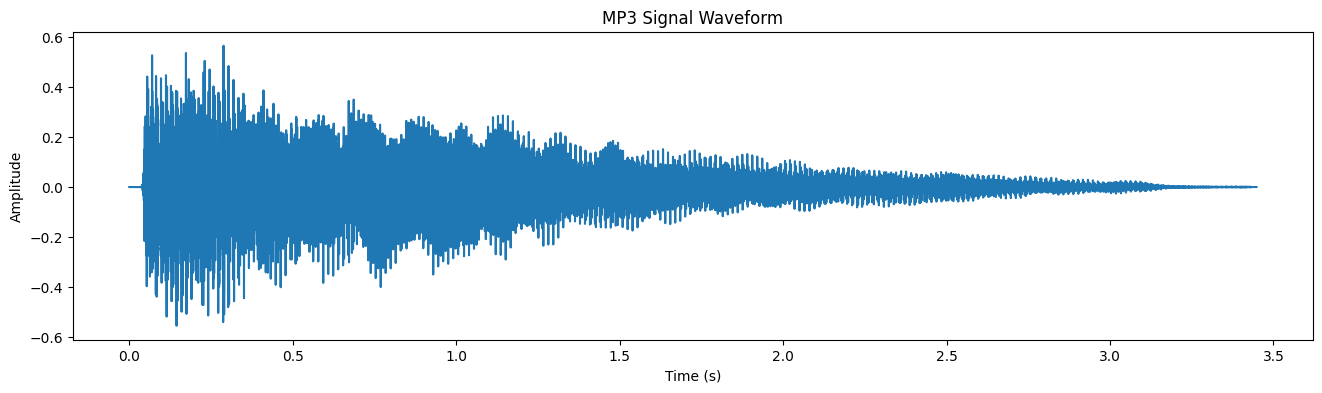

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 4))
plt.plot(times,signal)
plt.title("MP3 Signal Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

In [4]:
# Funciones 

def FFT(U):
    return np.fft.ifftshift(np.fft.fft(np.fft.fftshift(U), norm='ortho'))

def IFFT(U):
    return np.fft.ifftshift(np.fft.ifft(np.fft.fftshift(U), norm='ortho'))

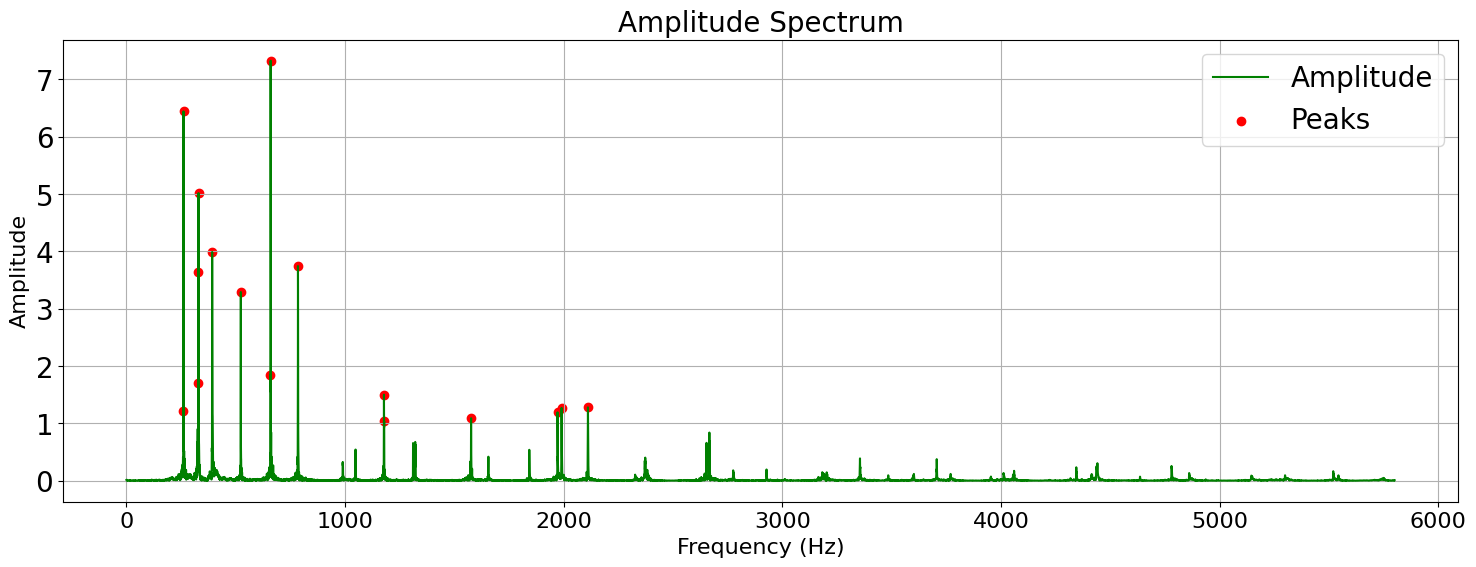

In [13]:
from scipy.signal import find_peaks

FT_signal = FFT(signal)

N = len(signal)
L = 20_000

real_part = FT_signal[N//2:N//2+L].real
imag_part = FT_signal[N//2:N//2+L].imag
amp_signal = np.abs(FT_signal[N//2:N//2+L])

peaks = find_peaks(amp_signal, height=1)  # Adjust height threshold as needed

xf = np.fft.fftfreq(N, 1 / sr)
frecuencias = xf[:L]


plt.figure(figsize=(18, 6))

plt.plot(frecuencias, amp_signal[:N//2], label='Amplitude', color='green')
plt.scatter(frecuencias[peaks[0]], amp_signal[peaks[0]], color='red', label='Peaks')

plt.title('Amplitude Spectrum',fontsize=20)
plt.xlabel('Frequency (Hz)',fontsize=16)
plt.ylabel('Amplitude',fontsize=16)

plt.xticks(fontsize=16)
plt.yticks(fontsize=20)

plt.grid()
plt.legend(fontsize=20)
# plt.tight_layout()
plt.show()


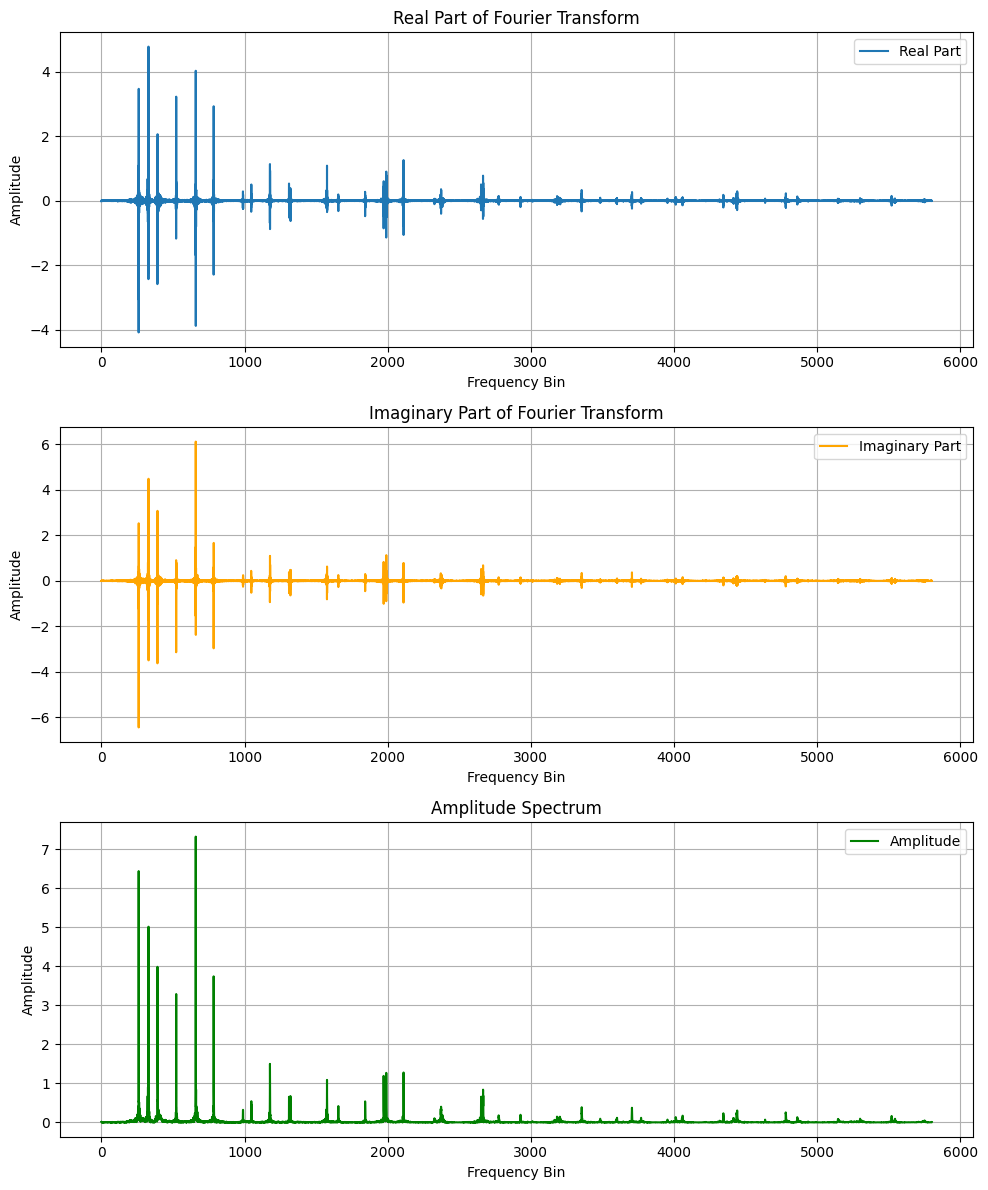

In [6]:
plt.figure(figsize=(10,12))
plt.subplot(3,1,1)
plt.plot(frecuencias, real_part, label='Real Part')
plt.title('Real Part of Fourier Transform')
plt.xlabel('Frequency Bin')
plt.ylabel('Amplitude')
plt.grid()
plt.legend()    

plt.subplot(3,1,2)
plt.plot(frecuencias, imag_part, label='Imaginary Part', color='orange')
plt.title('Imaginary Part of Fourier Transform')
plt.xlabel('Frequency Bin') 
plt.ylabel('Amplitude')
plt.grid()
plt.legend()

plt.subplot(3,1,3)
plt.plot(frecuencias, amp_signal, label='Amplitude', color='green')
plt.title('Amplitude Spectrum')
plt.xlabel('Frequency Bin')
plt.ylabel('Amplitude')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


Note que para el array de frecuencias usamos la funcion `np.fft.fftfreq()` con argumentos N y 1/sr, siendo N el numero de muestras y sr la frecuencia de sampleo. Esta función fftfreq esta diseñada para transformar correctamente el ancho de banda del espacio de coordenadas al de frecuencias. 

## Codigo de clase

Ahora usando la rutina `FT(x,y)` diseñada por el docente en clase, realizaremos la transformada de Fourier discreta de la señal

In [75]:
from scipy import interpolate
import numpy as np
import pandas as pd

def g(t, w):
    return 1./(2*np.pi)*np.exp(-1j*2*np.pi*w*t)

def FT(x, y, w_min=0.1, w_max=1200, n_w=300, n_int=2000):
    '''Integrate the Fourier Transform of f(t) at frequency w using manual trapezoidal rule'''

    f_interp = interpolate.interp1d(x, y, kind='cubic', fill_value='extrapolate')
    
    w = np.linspace(w_min, w_max, n_w) 

    # Creamos la grilla fina de tiempo para evaluar la función interpolada
    t_int = np.linspace(x.min(), x.max(), n_int)
    ft_vals = f_interp(t_int)
    
    # Calculamos el diferencial de tiempo entre puntos contiguos (dt)
    dt = np.diff(t_int)

    df = []
    for i in range(len(w)):
        # Evaluamos la base compleja completa
        z = ft_vals * g(t_int, w[i])
        
        # Integración por trapecio manual
        integral = np.sum((z[:-1] + z[1:]) * 0.5 * dt)
        
        # Extracción de componentes (se conserva la columna ANG del formato original)
        ARew = np.real(integral)
        AImw = np.imag(integral)
        AMP = np.abs(integral)
        ANG = np.arctan2(AImw, ARew)
        
        df.append([w[i], ARew, AImw, AMP, ANG])

    # DataFrame (Conserva las 5 columnas originales que requiere tu flujo)
    df = pd.DataFrame(df, columns=['w', 'ReTw', 'ImTw', 'AMP', 'ANG'])
    return df

In [76]:
segment_time = 0.2  # segundos
segment_samples = int(segment_time * sr) # ~8820 muestras

times_sub = np.arange(segment_samples) / sr
signal_sub = signal[:segment_samples]

# Ejecución con los parámetros idénticos a tu prueba de éxito
df = FT(times_sub, signal_sub, w_min=0.1, w_max=1200, n_w=300, n_int=2000)

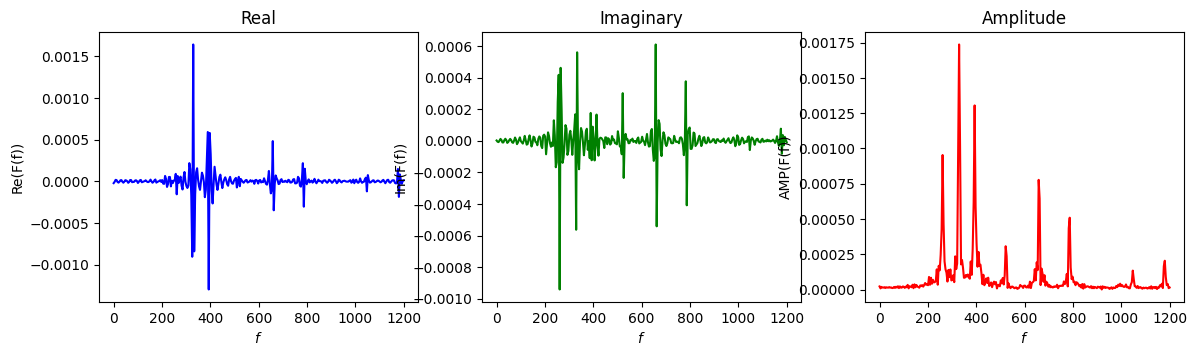

In [77]:


plt.figure(figsize=(14,3.5))
######## REAL ###########
plt.subplot(1,3,1)
plt.plot(df.w, df.ReTw,'b-')
plt.title('Real')
plt.xlabel('$f$')
plt.ylabel('Re(F(f))')
######### IMAG ##########
plt.subplot(1,3,2)
plt.plot(df.w, df.ImTw,'g-')
plt.title('Imaginary')
plt.xlabel('$f$')
plt.ylabel('Im(F(f))')
######### AMP ##########
plt.subplot(1,3,3)
plt.plot(df.w, df.AMP,'r-')
plt.title('Amplitude')
plt.xlabel('$f$')
plt.ylabel('AMP(F(f))')
plt.show()



300


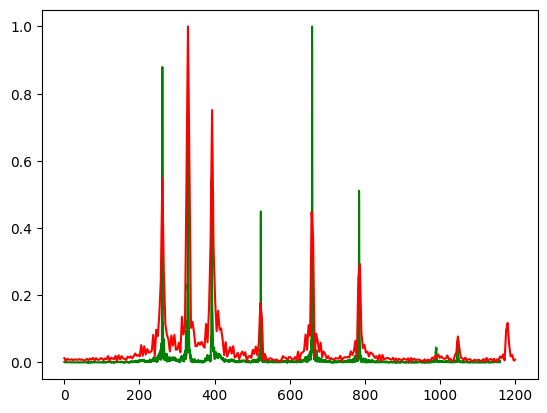

In [85]:
M = len(df.w)
print(M)

plt.plot(frecuencias[:4000], amp_signal[:4000]/np.max(amp_signal[:4000]), label='Amplitude', color='green')
plt.plot(df.w, df.AMP/np.max(df.AMP),'r-')